In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data.csv")
print(df.shape)
df.head()

(11914, 16)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [3]:
print(df.shape)
print(df.dtypes)

(11914, 16)
Make                  object
Model                 object
Year                   int64
Engine Fuel Type      object
Engine HP            float64
Engine Cylinders     float64
Transmission Type     object
Driven_Wheels         object
Number of Doors      float64
Market Category       object
Vehicle Size          object
Vehicle Style         object
highway MPG            int64
city mpg               int64
Popularity             int64
MSRP                   int64
dtype: object


In [4]:
print(df.isnull().sum())

Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64


In [6]:
df.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


In [3]:
df = df.dropna(subset=["Engine Fuel Type", "Number of Doors"])

In [4]:
df["Engine HP"] = df["Engine HP"].fillna(df["Engine HP"].median())
df["Engine Cylinders"] = df["Engine Cylinders"].fillna(df["Engine Cylinders"].median())

In [5]:
df["Market Category"] = df["Market Category"].fillna("Unknown")

In [6]:
print(df.isnull().sum())
print(f"\nRows remaining: {len(df)}")

Make                 0
Model                0
Year                 0
Engine Fuel Type     0
Engine HP            0
Engine Cylinders     0
Transmission Type    0
Driven_Wheels        0
Number of Doors      0
Market Category      0
Vehicle Size         0
Vehicle Style        0
highway MPG          0
city mpg             0
Popularity           0
MSRP                 0
dtype: int64

Rows remaining: 11905


In [7]:
print(df["MSRP"].describe())

count    1.190500e+04
mean     4.056021e+04
std      6.007645e+04
min      2.000000e+03
25%      2.100000e+04
50%      2.999500e+04
75%      4.220000e+04
max      2.065902e+06
Name: MSRP, dtype: float64


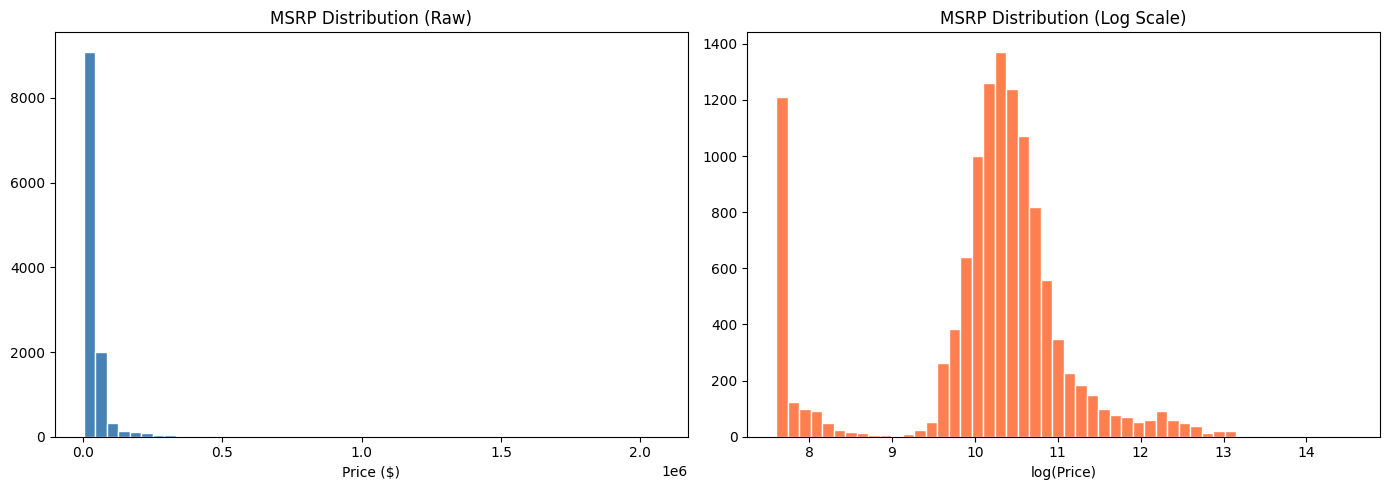

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].hist(df["MSRP"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("MSRP Distribution (Raw)")
axes[0].set_xlabel("Price ($)")


axes[1].hist(np.log1p(df["MSRP"]), bins=50, color="coral", edgecolor="white")
axes[1].set_title("MSRP Distribution (Log Scale)")
axes[1].set_xlabel("log(Price)")

plt.tight_layout()
plt.show()


In [9]:
print(df.dtypes)

Make                  object
Model                 object
Year                   int64
Engine Fuel Type      object
Engine HP            float64
Engine Cylinders     float64
Transmission Type     object
Driven_Wheels         object
Number of Doors      float64
Market Category       object
Vehicle Size          object
Vehicle Style         object
highway MPG            int64
city mpg               int64
Popularity             int64
MSRP                   int64
dtype: object


In [10]:
text_cols = ["Make", "Model", "Engine Fuel Type", 
             "Transmission Type", "Driven_Wheels",
             "Market Category", "Vehicle Size", "Vehicle Style"]

for col in text_cols:
    print(f"{col}: {df[col].nunique()} unique values")

Make: 48 unique values
Model: 915 unique values
Engine Fuel Type: 10 unique values
Transmission Type: 5 unique values
Driven_Wheels: 4 unique values
Market Category: 72 unique values
Vehicle Size: 3 unique values
Vehicle Style: 16 unique values


In [11]:
df = pd.get_dummies(df, 
    columns=["Make", "Engine Fuel Type", "Transmission Type", 
             "Driven_Wheels", "Vehicle Style"],
    drop_first=True)

print(f"Columns after one-hot encoding: {df.shape[1]}")

Columns after one-hot encoding: 89


In [12]:
size_order = {"Compact": 0, "Midsize": 1, "Large": 2}
df["Vehicle Size"] = df["Vehicle Size"].map(size_order)

print(df["Vehicle Size"].value_counts())

Vehicle Size
0    4764
1    4370
2    2771
Name: count, dtype: int64


In [13]:
df = df.drop(columns=["Model", "Market Category"])
print(f"Final shape: {df.shape}")

Final shape: (11905, 87)


In [14]:
# y = what we predict (log transformed)
y = np.log1p(df["MSRP"])

# X = everything else
X = df.drop(columns=["MSRP"])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (11905, 86)
y shape: (11905,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42     # same split every run
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")

Training samples: 9524
Test samples:     2381


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Train
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict
y_pred = lr.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"R²:  {r2:.4f}")
print(f"MAE (log scale): {mae:.4f}")

# Convert back to real dollars
mae_dollars = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))
print(f"Average price error: ${mae_dollars:,.0f}")

R²:  0.8593
MAE (log scale): 0.3087
Average price error: $11,109


In [17]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1        # use all CPU cores
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf  = r2_score(y_test, y_pred_rf)

print(f"R²:  {r2_rf:.4f}")
print(f"Average price error: ${mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_rf)):,.0f}")

R²:  0.9904
Average price error: $3,254


In [26]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print(f"R²:  {r2_score(y_test, y_pred_xgb):.4f}")
print(f"Average price error: ${mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_xgb)):,.0f}")

R²:  0.9928
Average price error: $3,101


In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth":     [4, 6, 8],
    "n_estimators":  [500, 1000]
}

grid_search = GridSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring="r2",
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV R²:  {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params: {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 1000}
Best CV R²:  0.9918


In [28]:
best_xgb = XGBRegressor(
    learning_rate=0.2,
    max_depth=4,
    n_estimators=1000,
    random_state=42,
    n_jobs=-1
)

best_xgb.fit(X_train, y_train)
y_pred_best = best_xgb.predict(X_test)

print(f"R²:  {r2_score(y_test, y_pred_best):.4f}")
print(f"Average price error: ${mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_best)):,.0f}")

R²:  0.9923
Average price error: $3,223


In [29]:
grid_search2 = GridSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    verbose=1
)

grid_search2.fit(X_train, y_train)
print(f"Best params: {grid_search2.best_params_}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 1000}


In [30]:
final_model = XGBRegressor(
    learning_rate=0.1,
    max_depth=6,
    n_estimators=1000,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train, y_train)
y_pred_final = final_model.predict(X_test)

print(f"R²:  {r2_score(y_test, y_pred_final):.4f}")
print(f"Average price error: ${mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_final)):,.0f}")

R²:  0.9928
Average price error: $3,101


In [32]:
import joblib
import os

# Create a folder for your saved artifacts
os.makedirs("artifacts", exist_ok=True)

# Save the model
joblib.dump(final_model, "artifacts/car_price_model.pkl")

# Save feature names — critical for correct column ordering later
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, "artifacts/feature_names.pkl")

print(f"Model saved!")
print(f"Features saved: {len(feature_names)} columns")

Model saved!
Features saved: 86 columns


In [33]:
# Calculate mean price per Make
make_encoding = df.groupby("Make")["MSRP"].mean()
print(make_encoding.sort_values(ascending=False).head(10))

KeyError: 'Make'

In [34]:
# Reload original data
df = pd.read_csv("data.csv")

# Clean again
df = df.dropna(subset=["Engine Fuel Type", "Number of Doors"])
df["Engine HP"] = df["Engine HP"].fillna(df["Engine HP"].median())
df["Engine Cylinders"] = df["Engine Cylinders"].fillna(df["Engine Cylinders"].median())
df["Market Category"] = df["Market Category"].fillna("Unknown")
df = df.dropna(subset=["MSRP"])

print(f"Shape: {df.shape}")
print("Data reloaded cleanly ✓")

Shape: (11905, 16)
Data reloaded cleanly ✓


In [35]:
# Target encode Make — replace each brand with its average MSRP
make_encoding = df.groupby("Make")["MSRP"].mean()
df["Make_encoded"] = df["Make"].map(make_encoding)

# Target encode Model
model_encoding = df.groupby("Model")["MSRP"].mean()
df["Model_encoded"] = df["Model"].map(model_encoding)

# Drop original text columns
df = df.drop(columns=["Make", "Model", "Market Category"])

print(df[["Make_encoded", "Model_encoded"]].head(10))

   Make_encoded  Model_encoded
0  61546.763473      46135.000
1  61546.763473      37853.125
2  61546.763473      37853.125
3  61546.763473      37853.125
4  61546.763473      37853.125
5  61546.763473      37853.125
6  61546.763473      37853.125
7  61546.763473      37853.125
8  61546.763473      37853.125
9  61546.763473      37853.125


In [36]:
# Label encode Vehicle Size
size_order = {"Compact": 0, "Midsize": 1, "Large": 2}
df["Vehicle Size"] = df["Vehicle Size"].map(size_order)

# One-hot encode remaining categorical columns
df = pd.get_dummies(df,
    columns=["Engine Fuel Type", "Transmission Type",
             "Driven_Wheels", "Vehicle Style"],
    drop_first=True)

# Build X and y
y = np.log1p(df["MSRP"])
X = df.drop(columns=["MSRP"])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"X shape: {X.shape}")
print(f"Columns: {X.shape[1]}")

X shape: (11905, 41)
Columns: 41


In [37]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

final_model_v2 = XGBRegressor(
    learning_rate=0.1,
    max_depth=6,
    n_estimators=1000,
    random_state=42,
    n_jobs=-1
)

final_model_v2.fit(X_train, y_train)
y_pred_v2 = final_model_v2.predict(X_test)

print(f"R²:  {r2_score(y_test, y_pred_v2):.4f}")
print(f"Average price error: ${mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_v2)):,.0f}")

R²:  0.9929
Average price error: $3,078


In [40]:
# Reload and clean again
df = pd.read_csv("data.csv")
df = df.dropna(subset=["Engine Fuel Type", "Number of Doors"])
df["Engine HP"] = df["Engine HP"].fillna(df["Engine HP"].median())
df["Engine Cylinders"] = df["Engine Cylinders"].fillna(df["Engine Cylinders"].median())
df["Market Category"] = df["Market Category"].fillna("Unknown")
df = df.dropna(subset=["MSRP"])

# Split BEFORE encoding this time
from sklearn.model_selection import train_test_split
import numpy as np

y = np.log1p(df["MSRP"])
X = df.drop(columns=["MSRP"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Now calculate encoding on TRAINING data only
make_encoding = X_train.join(y_train).groupby("Make")["MSRP"].mean()

# Hmm — but y_train is log transformed, not raw MSRP
# Let's use raw MSRP for encoding
train_df = X_train.copy()
train_df["MSRP"] = np.expm1(y_train)

make_encoding  = train_df.groupby("Make")["MSRP"].mean()
model_encoding = train_df.groupby("Model")["MSRP"].mean()

# Apply to both train and test
X_train["Make_encoded"]  = X_train["Make"].map(make_encoding)
X_test["Make_encoded"]   = X_test["Make"].map(make_encoding)

X_train["Model_encoded"] = X_train["Model"].map(model_encoding)
X_test["Model_encoded"]  = X_test["Model"].map(model_encoding)

# Drop original text columns
X_train = X_train.drop(columns=["Make", "Model", "Market Category"])
X_test  = X_test.drop(columns=["Make", "Model", "Market Category"])

print("Done — no data leakage this time ✓")




Done — no data leakage this time ✓


In [41]:
# Label encode Vehicle Size
size_order = {"Compact": 0, "Midsize": 1, "Large": 2}
X_train["Vehicle Size"] = X_train["Vehicle Size"].map(size_order)
X_test["Vehicle Size"]  = X_test["Vehicle Size"].map(size_order)

# One-hot encode remaining categorical columns
X_train = pd.get_dummies(X_train,
    columns=["Engine Fuel Type", "Transmission Type",
             "Driven_Wheels", "Vehicle Style"],
    drop_first=True)

X_test = pd.get_dummies(X_test,
    columns=["Engine Fuel Type", "Transmission Type",
             "Driven_Wheels", "Vehicle Style"],
    drop_first=True)

# Align columns — test might have different dummies than train
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")

Train shape: (9524, 41)
Test shape:  (2381, 41)


In [42]:
final_model_v3 = XGBRegressor(
    learning_rate=0.1,
    max_depth=6,
    n_estimators=1000,
    random_state=42,
    n_jobs=-1
)

final_model_v3.fit(X_train, y_train)
y_pred_v3 = final_model_v3.predict(X_test)

print(f"R²:  {r2_score(y_test, y_pred_v3):.4f}")
print(f"Average price error: ${mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_v3)):,.0f}")

R²:  0.9755
Average price error: $4,932


In [43]:
# Check if any Make/Model encodings are missing in test set
print("Missing Make encodings in test:")
print(X_test["Make_encoded"].isnull().sum())

print("Missing Model encodings in test:")
print(X_test["Model_encoded"].isnull().sum())

Missing Make encodings in test:
0
Missing Model encodings in test:
23


In [44]:
# Calculate global average as fallback
global_avg = np.expm1(y_train).mean()

# Fill missing model encodings with global average
X_train["Model_encoded"] = X_train["Model_encoded"].fillna(global_avg)
X_test["Model_encoded"]  = X_test["Model_encoded"].fillna(global_avg)

print(f"Global average price used as fallback: ${global_avg:,.0f}")
print(f"Missing after fix: {X_test['Model_encoded'].isnull().sum()}")

Global average price used as fallback: $40,696
Missing after fix: 0


In [45]:
final_model_v3 = XGBRegressor(
    learning_rate=0.1,
    max_depth=6,
    n_estimators=1000,
    random_state=42,
    n_jobs=-1
)

final_model_v3.fit(X_train, y_train)
y_pred_v3 = final_model_v3.predict(X_test)

print(f"R²:  {r2_score(y_test, y_pred_v3):.4f}")
print(f"Average price error: ${mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_v3)):,.0f}")

R²:  0.9910
Average price error: $3,259


In [46]:
import joblib
import os

os.makedirs("artifacts", exist_ok=True)

joblib.dump(final_model_v3, "artifacts/car_price_model.pkl")
joblib.dump(X_train.columns.tolist(), "artifacts/feature_names.pkl")
joblib.dump(make_encoding, "artifacts/make_encoding.pkl")
joblib.dump(model_encoding, "artifacts/model_encoding.pkl")
joblib.dump(global_avg, "artifacts/global_avg.pkl")

print("All artifacts saved ✓")

All artifacts saved ✓


In [47]:
import mlflow
import mlflow.xgboost

# Point to local MLflow server
mlflow.set_tracking_uri("http://127.0.0.1:5000")

# Name your experiment
mlflow.set_experiment("car-price-prediction")

with mlflow.start_run(run_name="xgboost-v4-no-leakage"):
    
    # Log parameters
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("n_estimators", 1000)
    mlflow.log_param("target_encoding", "no_leakage")
    mlflow.log_param("train_samples", len(X_train))
    
    # Log metrics
    mlflow.log_metric("r2", r2_score(y_test, y_pred_v3))
    mlflow.log_metric("mae_dollars", 
        mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_v3)))
    
    # Log the model
    mlflow.xgboost.log_model(final_model_v3, "model")
    
    print("Run logged to MLflow ✓")

2026/03/10 19:39:10 INFO mlflow.tracking.fluent: Experiment with name 'car-price-prediction' does not exist. Creating a new experiment.
2026/03/10 19:39:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run logged to MLflow ✓
🏃 View run xgboost-v4-no-leakage at: http://127.0.0.1:5000/#/experiments/1/runs/1adb0b9751574633b7edfe16c746c1e1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
